# Capstone 3: Data Wrangling & EDA
## Automated Dog Breed Identification from Shelter Photos

## 0. Setup

In [1]:
import os, re, hashlib, glob, warnings
import xml.etree.ElementTree as ET
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import imagehash

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

DATA_ROOT = r"C:\Users\alyss\data"
STANFORD_ROOT = os.path.join(DATA_ROOT, r"archive (1)")
PETFINDER_DIR = os.path.join(DATA_ROOT, r"petfinder-adoption-prediction")   
AUSTIN_CSV = r"C:\Users\alyss\data\Austin_Animal_Center_Outcomes_(10_01_2013_to_05_05_2025)_20260901.csv"

BREED_FOLDER_RE = re.compile(r"^n\d+-")

def find_breed_folders(root):
    """Walks the whole tree under `root` and returns {breed_folder_name: full_path}
    for every directory matching Stanford Dogs' 'n0123456-BreedName' naming --
    works regardless of how many levels of nesting the zip extracted to."""
    found = {}
    for dirpath, dirnames, _ in os.walk(root):
        for d in dirnames:
            if BREED_FOLDER_RE.match(d):
                found[d] = os.path.join(dirpath, d)
    return found

image_breed_dirs = find_breed_folders(os.path.join(STANFORD_ROOT, "images"))
annotation_breed_dirs = find_breed_folders(os.path.join(STANFORD_ROOT, "annotations"))
print(f"Found {len(image_breed_dirs)} breed image folders, {len(annotation_breed_dirs)} breed annotation folders.")

PETFINDER_TRAIN_CSV = os.path.join(PETFINDER_DIR, "train", "train.csv")
PETFINDER_AVAILABLE = (
    os.path.exists(PETFINDER_TRAIN_CSV)
    and os.path.exists(os.path.join(PETFINDER_DIR, "breed_labels.csv"))
)
print("PetFinder.my available:", PETFINDER_AVAILABLE)

Found 120 breed image folders, 120 breed annotation folders.
PetFinder.my available: True


## 1. Data Wrangling

### 1.1 Data Collection

**How each source is acquired (run once, outside this notebook, or in the cell below if you have API credentials configured):**

```bash
# Stanford Dogs Dataset (Kaggle) - also loadable via Hugging Face `datasets`
kaggle datasets download -d jessicali9530/stanford-dogs-dataset -p ./data/stanford_dogs --unzip

# PetFinder.my Adoption Prediction (Kaggle competition)
kaggle competitions download -c petfinder-adoption-prediction -p ./data/petfinder --unzip

# Austin Animal Center Outcomes (Austin open data portal, no auth needed)
curl -L "https://data.austintexas.gov/resource/9t4d-g238.csv?$limit=200000" -o ./data/austin/austin_outcomes.csv
```

In [2]:
# --- Stanford Dogs: build the manifest from the breed folders discovered in Setup ---
sd_records = []
for breed_dir, img_dir in image_breed_dirs.items():
    ann_dir = annotation_breed_dirs.get(breed_dir)
    for fname in os.listdir(img_dir):
        ann_path = None
        if ann_dir:
            candidate = os.path.join(ann_dir, os.path.splitext(fname)[0])  # real annotations have no extension
            if os.path.exists(candidate):
                ann_path = candidate
        sd_records.append({
            "image_path": os.path.join(img_dir, fname),
            "source": "stanford_dogs",
            "breed_raw": breed_dir,
            "annotation_path": ann_path,
        })
sd_df = pd.DataFrame(sd_records)
print(f"Stanford Dogs: {len(sd_df)} image records across {sd_df['breed_raw'].nunique()} breed folders")
sd_df.head(25)

Stanford Dogs: 20580 image records across 120 breed folders


,image_path,source,breed_raw,annotation_path
0,C:\Users\alyss\data\archive (1)\images\Images\...,stanford_dogs,n02085620-Chihuahua,C:\Users\alyss\data\archive (1)\annotations\An...
1,C:\Users\alyss\data\archive (1)\images\Images\...,stanford_dogs,n02085620-Chihuahua,C:\Users\alyss\data\archive (1)\annotations\An...
2,C:\Users\alyss\data\archive (1)\images\Images\...,stanford_dogs,n02085620-Chihuahua,C:\Users\alyss\data\archive (1)\annotations\An...
3,C:\Users\alyss\data\archive (1)\images\Images\...,stanford_dogs,n02085620-Chihuahua,C:\Users\alyss\data\archive (1)\annotations\An...
4,C:\Users\alyss\data\archive (1)\images\Images\...,stanford_dogs,n02085620-Chihuahua,C:\Users\alyss\data\archive (1)\annotations\An...
5,C:\Users\alyss\data\archive (1)\images\Images\...,stanford_dogs,n02085620-Chihuahua,C:\Users\alyss\data\archive (1)\annotations\An...
6,C:\Users\alyss\data\archive (1)\images\Images\...,stanford_dogs,n02085620-Chihuahua,C:\Users\alyss\data\archive (1)\annotations\An...
7,C:\Users\alyss\data\archive (1)\images\Images\...,stanford_dogs,n02085620-Chihuahua,C:\Users\alyss\data\archive (1)\annotations\An...
8,C:\Users\alyss\data\archive (1)\images\Images\...,stanford_dogs,n02085620-Chihuahua,C:\Users\alyss\data\archive (1)\annotations\An...
9,C:\Users\alyss\data\archive (1)\images\Images\...,stanford_dogs,n02085620-Chihuahua,C:\Users\alyss\data\archive (1)\annotations\An...


In [3]:
# --- PetFinder.my: join train.csv with breed_labels.csv (train.csv only has numeric Breed1,
# not a breed name column -- the join is required), filter to dogs, build image paths ---
if PETFINDER_AVAILABLE:
    pf_train = pd.read_csv(PETFINDER_TRAIN_CSV)
    breed_labels = pd.read_csv(os.path.join(PETFINDER_DIR, "breed_labels.csv"))
    breed_id_to_name = dict(zip(breed_labels["BreedID"], breed_labels["BreedName"]))

    n_not_dog = (pf_train["Type"] != 1).sum()
    n_zero_photos = ((pf_train["Type"] == 1) & (pf_train["PhotoAmt"] == 0)).sum()

    pf_records = []
    for _, row in pf_train.iterrows():
        if row["Type"] != 1:        # 1 = Dog, 2 = Cat -- PetFinder.my mixes both species
            continue
        if row["PhotoAmt"] == 0:    # no photo was ever uploaded for this listing -- not corrupt, just absent
            continue
        breed_name = breed_id_to_name.get(row["Breed1"], "Unknown")
        img_path = os.path.join(PETFINDER_DIR, "train_images", f"{row['PetID']}-1.jpg")
        pf_records.append({
            "image_path": img_path,
            "source": "petfinder",
            "breed_raw": breed_name,
            "annotation_path": None,
        })
    pf_df = pd.DataFrame(pf_records)
    print(f"PetFinder.my: {len(pf_train)} total rows -> dropped {n_not_dog} non-dog rows, "
          f"{n_zero_photos} dog rows with zero uploaded photos -> {len(pf_df)} usable rows")
else:
    pf_df = pd.DataFrame(columns=["image_path", "source", "breed_raw", "annotation_path"])
    print("Skipping PetFinder.my for now (0 rows) -- everything below still runs on Stanford Dogs + Austin.")
pf_df.head(25)

PetFinder.my: 14993 total rows -> dropped 6861 non-dog rows, 194 dog rows with zero uploaded photos -> 7938 usable rows


,image_path,source,breed_raw,annotation_path
0,C:\Users\alyss\data\petfinder-adoption-predict...,petfinder,Mixed Breed,None
1,C:\Users\alyss\data\petfinder-adoption-predict...,petfinder,Mixed Breed,None
2,C:\Users\alyss\data\petfinder-adoption-predict...,petfinder,Mixed Breed,None
3,C:\Users\alyss\data\petfinder-adoption-predict...,petfinder,Mixed Breed,None
4,C:\Users\alyss\data\petfinder-adoption-predict...,petfinder,Mixed Breed,None
5,C:\Users\alyss\data\petfinder-adoption-predict...,petfinder,Mixed Breed,None
6,C:\Users\alyss\data\petfinder-adoption-predict...,petfinder,Mixed Breed,None
7,C:\Users\alyss\data\petfinder-adoption-predict...,petfinder,Terrier,None
8,C:\Users\alyss\data\petfinder-adoption-predict...,petfinder,Mixed Breed,None
9,C:\Users\alyss\data\petfinder-adoption-predict...,petfinder,Mixed Breed,None


In [4]:
# --- Austin Animal Center Outcomes: tabular context only, kept separate from the image manifest ---
austin_df = pd.read_csv(AUSTIN_CSV)
print("Austin CSV columns:", list(austin_df.columns))  # verify these match what the code below expects
austin_df = austin_df[austin_df["Animal Type"] == "Dog"].copy()
print(f"Austin Outcomes: {len(austin_df)} dog outcome records (context/framing data, no images)")
austin_df.head()


Austin CSV columns: ['Animal ID', 'Date of Birth', 'Name', 'DateTime', 'MonthYear', 'Outcome Type', 'Outcome Subtype', 'Animal Type', 'Sex upon Outcome', 'Age upon Outcome', 'Breed', 'Color']
Austin Outcomes: 94505 dog outcome records (context/framing data, no images)


,Animal ID,Date of Birth,Name,DateTime,MonthYear,Outcome Type,Outcome Subtype,Animal Type,Sex upon Outcome,Age upon Outcome,Breed,Color
12,A683090,2014-04-22,Jenny Tyson,2014-07-11T00:00:00-05:00,07-2014,Adoption,NaN,Dog,Spayed Female,2 months,Black Mouth Cur Mix,Brown/Black
21,A693750,2013-12-14,*Stetson,2014-12-23T00:00:00-05:00,12-2014,Transfer,Partner,Dog,Intact Male,1 year,Chihuahua Shorthair Mix,Brown/White
23,A694191,2014-04-22,NaN,2014-12-27T00:00:00-05:00,12-2014,Transfer,Partner,Dog,Intact Male,8 months,Shiba Inu Mix,Tan
26,A694136,2009-01-02,Hershey,2014-12-31T00:00:00-05:00,12-2014,Return to Owner,NaN,Dog,Neutered Male,5 years,Cocker Spaniel Mix,Chocolate
27,A604679,2008-12-27,Snowball,2015-01-01T00:00:00-05:00,01-2015,Transfer,Partner,Dog,Neutered Male,6 years,Chihuahua Shorthair Mix,Cream


### 1.2 Data Organization

Combine Stanford Dogs and PetFinder.my into a single image manifest with a common schema,
so wrangling/EDA logic runs once across both sources instead of twice. Austin stays separate
since it's tabular context, not part of the image pipeline.


In [5]:
manifest = pd.concat([sd_df, pf_df], ignore_index=True)
print(f"Combined image manifest: {len(manifest)} rows ({manifest['source'].value_counts().to_dict()})")
manifest.head()

Combined image manifest: 28518 rows ({'stanford_dogs': 20580, 'petfinder': 7938})


,image_path,source,breed_raw,annotation_path
0,C:\Users\alyss\data\archive (1)\images\Images\...,stanford_dogs,n02085620-Chihuahua,C:\Users\alyss\data\archive (1)\annotations\An...
1,C:\Users\alyss\data\archive (1)\images\Images\...,stanford_dogs,n02085620-Chihuahua,C:\Users\alyss\data\archive (1)\annotations\An...
2,C:\Users\alyss\data\archive (1)\images\Images\...,stanford_dogs,n02085620-Chihuahua,C:\Users\alyss\data\archive (1)\annotations\An...
3,C:\Users\alyss\data\archive (1)\images\Images\...,stanford_dogs,n02085620-Chihuahua,C:\Users\alyss\data\archive (1)\annotations\An...
4,C:\Users\alyss\data\archive (1)\images\Images\...,stanford_dogs,n02085620-Chihuahua,C:\Users\alyss\data\archive (1)\annotations\An...


### 1.3 Data Definition

| Column | Type | Meaning |
|---|---|---|
| `image_path` | str | Path to the image file on disk |
| `source` | str | `stanford_dogs` (training) or `petfinder` (real-world validation) |
| `breed_raw` | str | Breed label as given by the source (different vocabularies — harmonized below) |
| `annotation_path` | str/None | Path to bounding-box annotation, Stanford Dogs only |
| `breed_harmonized` | str | Breed label mapped to a common vocabulary across sources (added in 1.4) |
| `width`, `height` | int | Image dimensions in pixels |
| `aspect_ratio` | float | width / height |
| `filesize_bytes` | int | File size on disk |
| `mean_brightness` | float | Mean pixel intensity (0-255), proxy for lighting/exposure |
| `mean_r`, `mean_g`, `mean_b` | float | Per-channel mean intensity |
| `is_corrupt` | bool | Failed to open / unreadable |
| `is_duplicate` | bool | Exact duplicate (MD5) of another image already in the manifest |


### 1.4 Data Cleaning

Working through each cleaning decision explicitly, with the reasoning for each:


**(a) Corrupt / unreadable files.** Try opening every file; anything that fails
(truncated, zero-byte, non-image) is dropped — a corrupt file can't be used for training
or EDA regardless of what its filename claims.

In [6]:
def check_image(path):
    """Returns (is_corrupt, width, height, mode) for a single image file."""
    try:
        with Image.open(path) as img:
            img.verify()
        with Image.open(path) as img:  # re-open: verify() invalidates the file handle
            w, h = img.size
            mode = img.mode
        return False, w, h, mode
    except Exception:
        return True, None, None, None

results = manifest["image_path"].apply(check_image)
manifest["is_corrupt"] = results.apply(lambda r: r[0])
manifest["width"] = results.apply(lambda r: r[1])
manifest["height"] = results.apply(lambda r: r[2])
manifest["mode"] = results.apply(lambda r: r[3])
manifest["aspect_ratio"] = manifest["width"] / manifest["height"]

n_corrupt = manifest["is_corrupt"].sum()
print(f"Corrupt/unreadable files found: {n_corrupt}")
manifest[manifest["is_corrupt"]][["image_path", "source"]]

Corrupt/unreadable files found: 0


,image_path,source


In [7]:
# Decision: drop corrupt files -- they can't be read for training or EDA.
manifest = manifest[~manifest["is_corrupt"]].reset_index(drop=True)
print(f"Manifest after dropping corrupt files: {len(manifest)} rows")

Manifest after dropping corrupt files: 28518 rows


**(b) Exact duplicates.** Hash file bytes (MD5); if two rows hash identically, one is a
byte-for-byte copy of the other. Decision: keep the first occurrence, drop the rest — an
exact duplicate provides no new information and would let the same image appear in both
train and test splits later.

In [8]:
def md5_of_file(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

manifest["file_hash"] = manifest["image_path"].apply(md5_of_file)
dupe_mask = manifest.duplicated(subset="file_hash", keep="first")
print(f"Exact duplicate files found: {dupe_mask.sum()}")
manifest[dupe_mask][["image_path", "source", "breed_raw"]]

Exact duplicate files found: 146


,image_path,source,breed_raw
986,C:\Users\alyss\data\archive (1)\images\Images\...,stanford_dogs,n02086646-Blenheim_spaniel
1033,C:\Users\alyss\data\archive (1)\images\Images\...,stanford_dogs,n02086646-Blenheim_spaniel
1114,C:\Users\alyss\data\archive (1)\images\Images\...,stanford_dogs,n02086646-Blenheim_spaniel
1142,C:\Users\alyss\data\archive (1)\images\Images\...,stanford_dogs,n02086910-papillon
2412,C:\Users\alyss\data\archive (1)\images\Images\...,stanford_dogs,n02088466-bloodhound
...,...,...,...
28245,C:\Users\alyss\data\petfinder-adoption-predict...,petfinder,Mixed Breed
28260,C:\Users\alyss\data\petfinder-adoption-predict...,petfinder,Mixed Breed
28417,C:\Users\alyss\data\petfinder-adoption-predict...,petfinder,Mixed Breed
28428,C:\Users\alyss\data\petfinder-adoption-predict...,petfinder,Mixed Breed


In [9]:
manifest = manifest[~dupe_mask].reset_index(drop=True)
print(f"Manifest after dropping exact duplicates: {len(manifest)} rows")

Manifest after dropping exact duplicates: 28372 rows


**(c) Near-duplicates (perceptual hash).** Some shelter/rescue photos are near-identical
burst shots of the same animal rather than byte-identical files. Perceptual hashing catches
these. Decision: *flag*, don't auto-drop — near-duplicates of the same real dog are still
useful training signal, unlike exact duplicates, so this is reported for awareness rather
than acted on automatically.

In [10]:
def phash_of_file(path):
    try:
        return str(imagehash.phash(Image.open(path)))
    except Exception:
        return None

manifest["phash"] = manifest["image_path"].apply(phash_of_file)
near_dupe_mask = manifest.duplicated(subset=["source", "breed_raw", "phash"], keep=False) & ~dupe_mask.reindex(manifest.index, fill_value=False)
print(f"Near-duplicate candidates flagged (same breed+source, matching perceptual hash): {near_dupe_mask.sum()}")

Near-duplicate candidates flagged (same breed+source, matching perceptual hash): 65


**(d) Channel/mode normalization.** CNNs expect consistent 3-channel RGB input;
grayscale or RGBA images will break batch loading. Decision: convert non-RGB images to RGB
rather than dropping them — the image content is still usable, only the color encoding needs
fixing. Important: this conversion happens **only on the processed copy** created in step
(g) below, never by overwriting the raw source file — raw data stays untouched and every
step here stays re-runnable without cumulative side effects.

In [11]:
non_rgb_count = (manifest["mode"] != "RGB").sum()
print(f"Non-RGB images found (will be converted on the processed copy, not the raw file): {non_rgb_count}")
print(manifest["mode"].value_counts())

Non-RGB images found (will be converted on the processed copy, not the raw file): 4
mode
RGB     28368
L           3
RGBA        1
Name: count, dtype: int64


**(e) Breed taxonomy harmonization.** Stanford Dogs and PetFinder.my use different breed
vocabularies (folder names like `n02093428-American_Staffordshire_terrier` vs. free-text
`BreedName` strings). They need to be mapped to one shared label set before the model can be
evaluated across both. Decision: build an explicit mapping; anything on the PetFinder side
with no reasonable Stanford Dogs equivalent (e.g., `Mixed Breed`, or breeds Stanford Dogs
doesn't cover) is kept as `no_match` — those rows are retained for the PetFinder-side EDA
below, but excluded from direct breed-for-breed model evaluation later, since there's no
ground truth to compare against.

In [12]:
import re, difflib

def clean_stanford_breed(folder_name):
    name = re.sub(r"^n\d+-", "", folder_name)
    return name.replace("_", " ").title()

manifest.loc[manifest["source"] == "stanford_dogs", "breed_harmonized"] = (
    manifest.loc[manifest["source"] == "stanford_dogs", "breed_raw"].apply(clean_stanford_breed)
)

# Collapse same-breed size/coat variants BEFORE building the match target list, so PetFinder's
# generic "Corgi"/"Poodle"/"Schnauzer" resolve as normal exact matches -- no special-casing needed.
GROUP_COLLAPSE = {
    "Pembroke": "Corgi", "Cardigan": "Corgi",
    "Toy Poodle": "Poodle", "Miniature Poodle": "Poodle", "Standard Poodle": "Poodle",
    "Miniature Schnauzer": "Schnauzer", "Giant Schnauzer": "Schnauzer", "Standard Schnauzer": "Schnauzer",
}
manifest["breed_harmonized"] = manifest["breed_harmonized"].replace(GROUP_COLLAPSE)

def normalize(name):
    name = re.sub(r"\(.*?\)", "", str(name))
    name = name.lower().strip()
    name = re.sub(r"[_\-]", " ", name)
    name = re.sub(r"\s+", " ", name)
    return name

NON_BREED = {"mixed breed", "domestic short hair", "domestic long hair", "domestic medium hair"}
STANFORD_SYNONYMS = {
    "boston terrier": "boston bull", "pekingese": "pekinese", "lhasa apso": "lhasa",
    "brussels griffon": "brabancon griffon", "doberman pinscher": "doberman",
    "alaskan malamute": "malamute", "xoloitzcuintli": "mexican hairless",
    "rough collie": "collie", "bullmastiff": "bull mastiff", "american eskimo dog": "eskimo dog",
}

stanford_breed_names = sorted(manifest.loc[manifest["source"] == "stanford_dogs", "breed_harmonized"].unique())
stanford_norm_map = {normalize(b): b for b in stanford_breed_names}

def token_subset_match(pf_norm):
    pf_tokens = set(pf_norm.split())
    candidates = [d for n, d in stanford_norm_map.items()
                  if pf_tokens.issubset(set(n.split())) or set(n.split()).issubset(pf_tokens)]
    return candidates[0] if len(candidates) == 1 else None

def match_petfinder_breed(pf_name, cutoff=0.82):
    norm = normalize(pf_name)
    if norm in NON_BREED:
        return "no_match", "excluded (not a specific breed)", None
    if norm in stanford_norm_map:
        return stanford_norm_map[norm], "exact", 1.0
    synonym = STANFORD_SYNONYMS.get(norm)
    if synonym and synonym in stanford_norm_map:
        return stanford_norm_map[synonym], "known synonym", 1.0
    token_match = token_subset_match(norm)
    if token_match:
        return token_match, "token-subset", None
    close = difflib.get_close_matches(norm, stanford_norm_map.keys(), n=1, cutoff=cutoff)
    if close:
        score = round(difflib.SequenceMatcher(None, norm, close[0]).ratio(), 2)
        return stanford_norm_map[close[0]], "fuzzy", score
    return "no_match", "no close match", None

unique_pf_breeds = manifest.loc[manifest["source"] == "petfinder", "breed_raw"].unique()
audit_rows = [(b,) + match_petfinder_breed(b) for b in unique_pf_breeds]
audit_df = pd.DataFrame(audit_rows, columns=["petfinder_breed", "matched_to", "method", "score"]).sort_values("method")
print(audit_df.to_string(index=False))

breed_lookup = {row["petfinder_breed"]: row["matched_to"] for _, row in audit_df.iterrows()}
manifest.loc[manifest["source"] == "petfinder", "breed_harmonized"] = (
    manifest.loc[manifest["source"] == "petfinder", "breed_raw"].map(breed_lookup)
)

no_match_count = (manifest["breed_harmonized"] == "no_match").sum()
print(f"\nPetFinder rows with no Stanford Dogs breed equivalent (kept, flagged 'no_match'): {no_match_count}")
manifest["breed_harmonized"].value_counts().head(15)

                              petfinder_breed                     matched_to                          method  score
                                    Chihuahua                      Chihuahua                           exact   1.00
                                        Corgi                          Corgi                           exact   1.00
                           Miniature Pinscher             Miniature Pinscher                           exact   1.00
                                        Boxer                          Boxer                           exact   1.00
                                      Basenji                        Basenji                           exact   1.00
                                       Kuvasz                         Kuvasz                           exact   1.00
                           Bedlington Terrier             Bedlington Terrier                           exact   1.00
                                          Pug                           

breed_harmonized
no_match              6275
Poodle                 619
Schnauzer              522
Shih-Tzu               390
Labrador Retriever     388
Corgi                  351
Golden Retriever       292
Beagle                 279
Maltese Dog            269
German Shepherd        253
Siberian Husky         251
Miniature Pinscher     250
Pomeranian             240
Afghan Hound           239
Rottweiler             235
Name: count, dtype: int64

**(f) Bounding-box crop (Stanford Dogs only).** Stanford Dogs ships bounding-box
annotations per image. Cropping to the box before resizing removes background clutter —
the closest practical equivalent to "segmentation" for this dataset, since no pixel-level
masks are available. Decision: crop only where an annotation file exists; leave others
uncropped rather than guessing a box. Counted here as a diagnostic; the actual crop is
applied in step (g), on the processed copy only — **the raw file is never overwritten**,
so this notebook can be re-run any number of times against the same raw download and always
produce the same result.

In [13]:
def has_bbox(row):
    return row["source"] == "stanford_dogs" and row["annotation_path"] is not None

will_crop = manifest.apply(has_bbox, axis=1)
print(f"Images with a bounding-box annotation available (will be cropped on the processed copy): {will_crop.sum()}")

Images with a bounding-box annotation available (will be cropped on the processed copy): 20491


**(g) Scale thresholding (standardized resize) — the only step that writes
processed files to disk.** Reads each raw image fresh, applies (in memory, in this order)
bounding-box crop where available → RGB normalization → resize to 224×224 (standard
ImageNet-pretrained input size, matching the Hugging Face Model Hub checkpoints this project
fine-tunes) → saves to a separate processed directory. Raw files are opened read-only
throughout. `width`/`height`/`aspect_ratio` used for EDA below are the pre-crop, pre-resize
values captured back in step (a), so they reflect the true, unmodified source data.

In [14]:
RESIZED_DIR = "./data/_resized_224"
os.makedirs(RESIZED_DIR, exist_ok=True)

def process_and_save(row, size=(224, 224)):
    out_path = os.path.join(RESIZED_DIR, f"{row.name}.jpg")
    with Image.open(row["image_path"]) as img:          # raw file opened read-only
        img = img.convert("RGB")
        if row["source"] == "stanford_dogs" and row["annotation_path"] and os.path.exists(str(row["annotation_path"])):
            tree = ET.parse(row["annotation_path"])     # real Stanford Dogs files are Pascal VOC XML, no file extension
            bbox = tree.find(".//object/bndbox")
            if bbox is not None:
                xmin = int(bbox.find("xmin").text)
                ymin = int(bbox.find("ymin").text)
                xmax = int(bbox.find("xmax").text)
                ymax = int(bbox.find("ymax").text)
                img = img.crop((xmin, ymin, xmax, ymax))
        img.resize(size, Image.BILINEAR).save(out_path, quality=90)
    return out_path

manifest["resized_path"] = manifest.apply(process_and_save, axis=1)
print(f"Processed (cropped where applicable, RGB-normalized, resized to 224x224): "
      f"{len(manifest)} images -> {RESIZED_DIR} (raw files untouched)")

Processed (cropped where applicable, RGB-normalized, resized to 224x224): 28372 images -> ./data/_resized_224 (raw files untouched)


**(h) Filter demonstration.** Applied a filter on one sample image for inspection —
edge detection is a reasonable diagnostic filter, useful for spot-checking whether a
photo actually contains a clear subject outline versus a blurry/obstructed shelter photo.

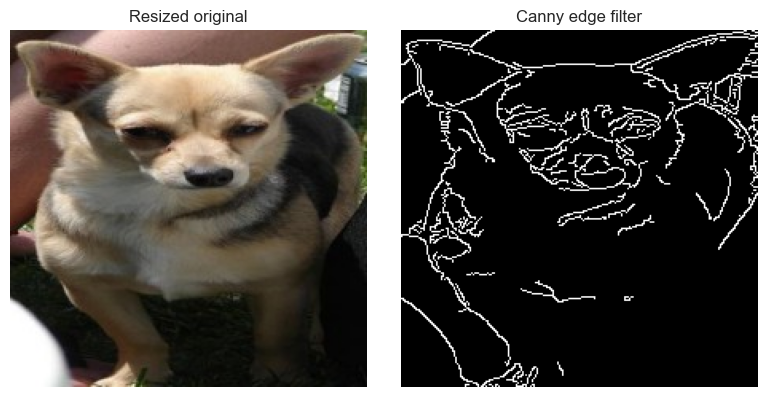

In [15]:
import cv2

sample_path = manifest.iloc[0]["resized_path"]
img_bgr = cv2.imread(sample_path)
edges = cv2.Canny(img_bgr, 100, 200)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)); axes[0].set_title("Resized original"); axes[0].axis("off")
axes[1].imshow(edges, cmap="gray"); axes[1].set_title("Canny edge filter"); axes[1].axis("off")
plt.tight_layout(); plt.show()

**(i) Meta-feature extraction (brightness, per-channel color).** These aren't model
inputs directly, but they're the features EDA below uses to check for domain shift between
Stanford Dogs (clean/staged) and PetFinder.my (real/messy) — directly relevant to the
constraint flagged in the project proposal.

In [16]:
def color_stats(path):
    with Image.open(path) as img:
        arr = np.array(img.convert("RGB")).astype(np.float32)
    return arr.mean(), arr[:,:,0].mean(), arr[:,:,1].mean(), arr[:,:,2].mean()

stats = manifest["image_path"].apply(color_stats)
manifest["mean_brightness"] = stats.apply(lambda s: s[0])
manifest["mean_r"] = stats.apply(lambda s: s[1])
manifest["mean_g"] = stats.apply(lambda s: s[2])
manifest["mean_b"] = stats.apply(lambda s: s[3])
manifest["filesize_bytes"] = manifest["image_path"].apply(os.path.getsize)
manifest[["width","height","aspect_ratio","mean_brightness","filesize_bytes"]].describe()

,width,height,aspect_ratio,mean_brightness,filesize_bytes
count,28372.000000,28372.000000,28372.000000,28372.000000,2.837200e+04
mean,425.826907,390.887671,1.132882,114.500420,3.544138e+04
std,140.252925,117.559741,0.330029,26.913086,2.989166e+04
min,60.000000,67.000000,0.302500,17.881773,1.672000e+03
25%,335.000000,333.000000,0.750000,96.964478,2.128425e+04
50%,420.000000,375.000000,1.326260,114.348171,3.049850e+04
75%,500.000000,480.000000,1.333333,131.290943,4.259325e+04
max,3264.000000,2562.000000,4.395604,237.094772,1.123937e+06


**(j) Outlier detection.** Flag images with implausible aspect ratios (panoramic crops,
likely not a usable dog photo) or extreme brightness (likely blown-out or near-black,
uninformative for classification). Decision: drop aspect-ratio outliers (almost certainly
not usable photos); keep brightness outliers but flag them, since a genuinely dark/bright
real shelter photo is still valid signal, not necessarily corrupt.

In [17]:
ar_low, ar_high = manifest["aspect_ratio"].quantile([0.01, 0.99])
ar_outlier_mask = (manifest["aspect_ratio"] < 0.4) | (manifest["aspect_ratio"] > 2.5)
print(f"Aspect-ratio outliers (dropped): {ar_outlier_mask.sum()}")
manifest = manifest[~ar_outlier_mask].reset_index(drop=True)

brightness_low, brightness_high = manifest["mean_brightness"].quantile([0.01, 0.99])
manifest["brightness_outlier"] = (
    (manifest["mean_brightness"] < brightness_low) | (manifest["mean_brightness"] > brightness_high)
)
print(f"Brightness outliers (flagged, not dropped): {manifest['brightness_outlier'].sum()}")

Aspect-ratio outliers (dropped): 17
Brightness outliers (flagged, not dropped): 568


**(k) Class imbalance check.** Determines whether stratified sampling / class weighting
will be needed for training (Stanford Dogs) and whether raw accuracy is trustworthy for the
PetFinder validation step (addressed in Criteria for Success in the proposal).

In [18]:
min_class_n = manifest[manifest["source"]=="stanford_dogs"]["breed_harmonized"].value_counts().min()
max_class_n = manifest[manifest["source"]=="stanford_dogs"]["breed_harmonized"].value_counts().max()
print(f"Stanford Dogs class counts range: {min_class_n} to {max_class_n} images/breed")
print("\nPetFinder breed_harmonized distribution (includes 'no_match'):")
print(manifest[manifest["source"]=="petfinder"]["breed_harmonized"].value_counts())

Stanford Dogs class counts range: 143 to 463 images/breed

PetFinder breed_harmonized distribution (includes 'no_match'):
breed_harmonized
no_match              6265
Labrador Retriever     217
Shih-Tzu               176
Poodle                 158
Golden Retriever       141
                      ... 
Bedlington Terrier       1
Samoyed                  1
Kuvasz                   1
Airedale                 1
English Foxhound         1
Name: count, Length: 62, dtype: int64


## 2. Exploratory Data Analysis

### 2.1 Response variable balance

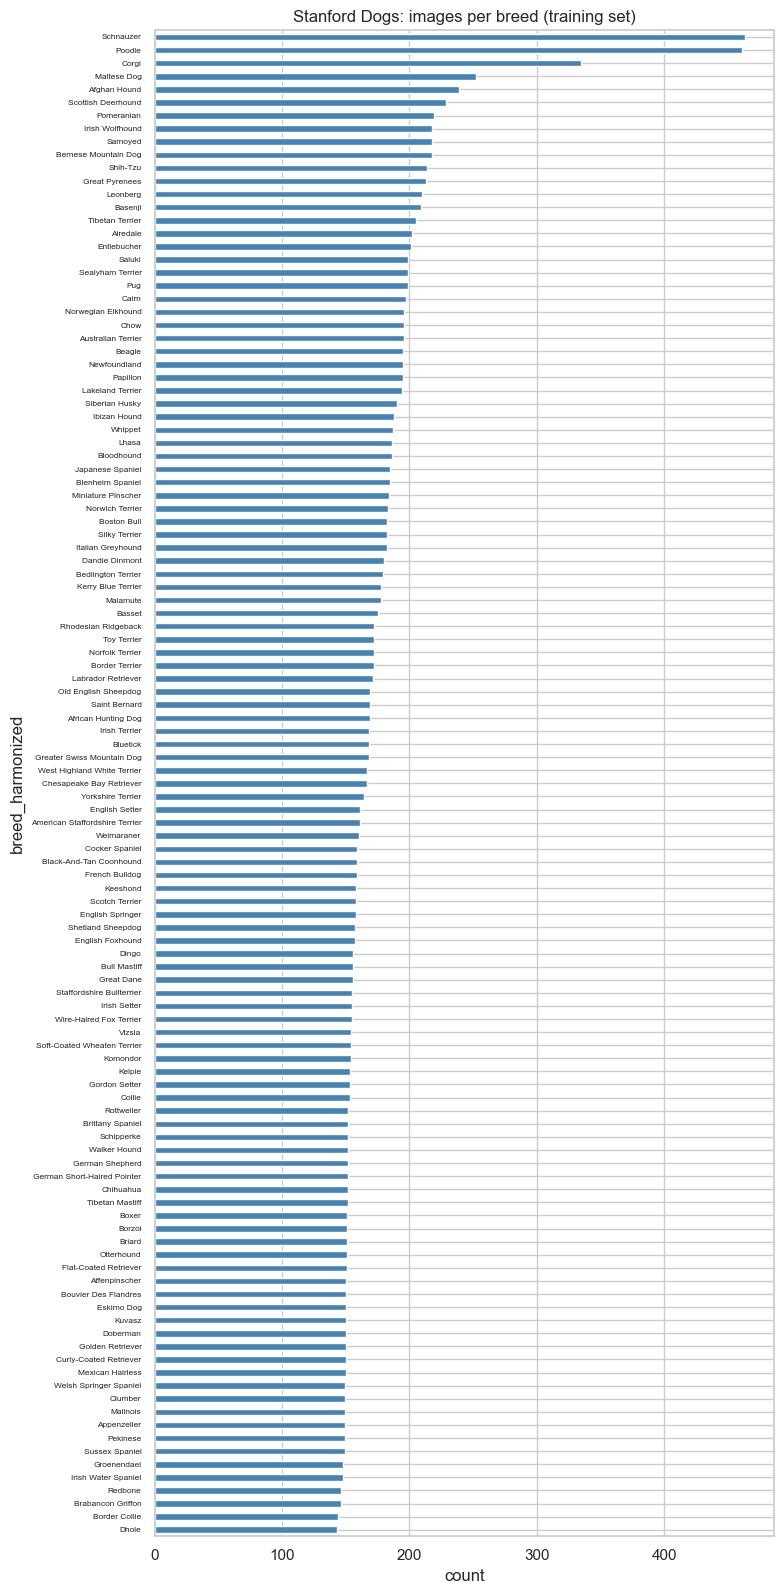

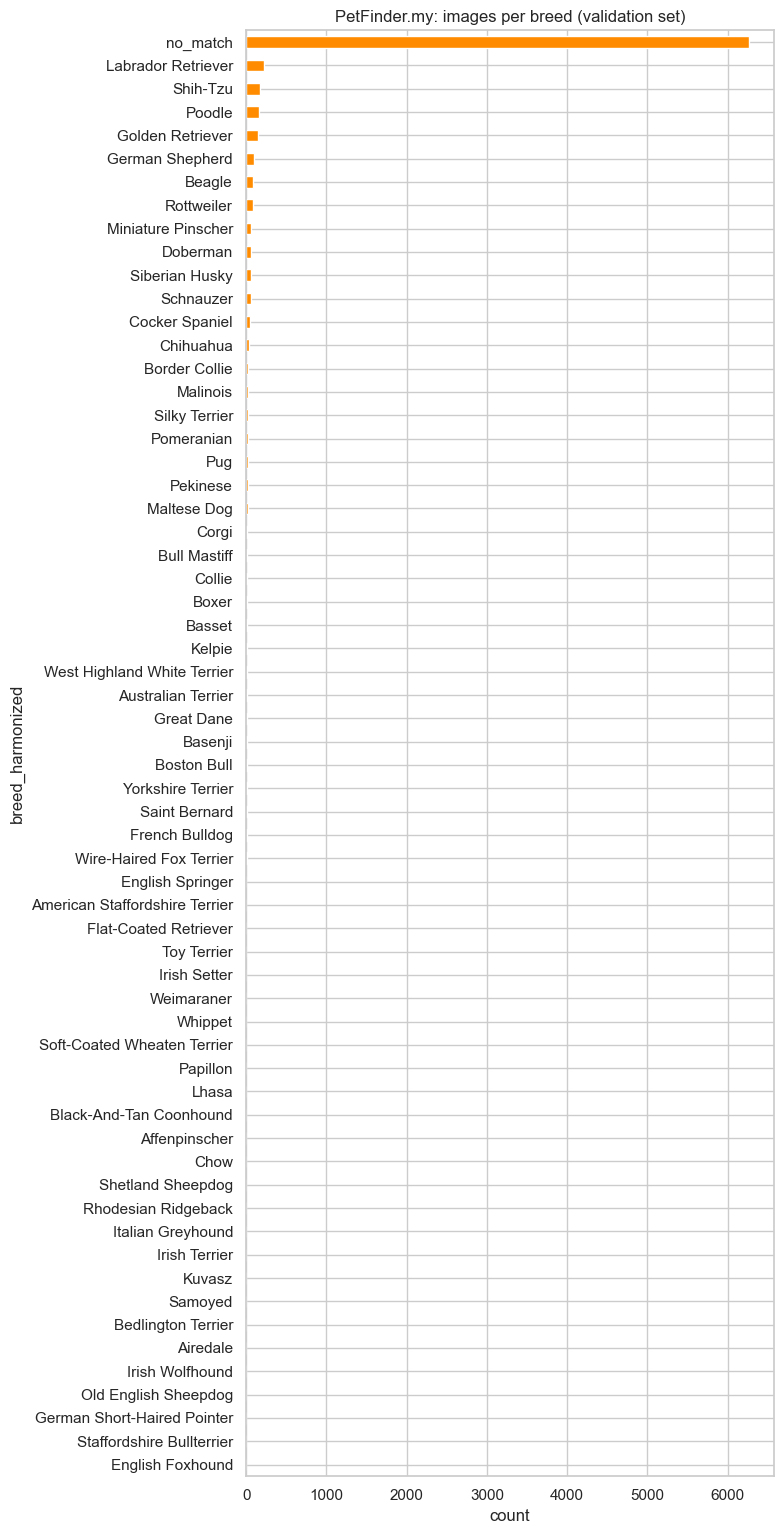

In [19]:
sd_counts = manifest[manifest["source"]=="stanford_dogs"]["breed_harmonized"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(8, max(6, len(sd_counts) * 0.14)))
sd_counts.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Stanford Dogs: images per breed (training set)")
ax.set_xlabel("count")
ax.tick_params(axis="y", labelsize=6)
plt.tight_layout()
plt.show()

pf_counts = manifest[manifest["source"]=="petfinder"]["breed_harmonized"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(8, max(4, len(pf_counts) * 0.25)))
if len(pf_counts) > 0:
    pf_counts.plot(kind="barh", ax=ax, color="darkorange")
    ax.set_title("PetFinder.my: images per breed (validation set)")
    ax.set_xlabel("count")
else:
    ax.text(0.5, 0.5, "PetFinder.my not loaded yet", ha="center", va="center", transform=ax.transAxes)
    ax.set_title("PetFinder.my: images per breed (validation set)")
plt.tight_layout()
plt.show()

### 2.2 Feature distributions (every numeric feature, by source)

Comparing Stanford Dogs vs. PetFinder.my directly tests the domain-mismatch constraint
named in the project proposal: if these distributions look very different, that's
evidence the model will need to generalize across a real gap, not just theorize about one.


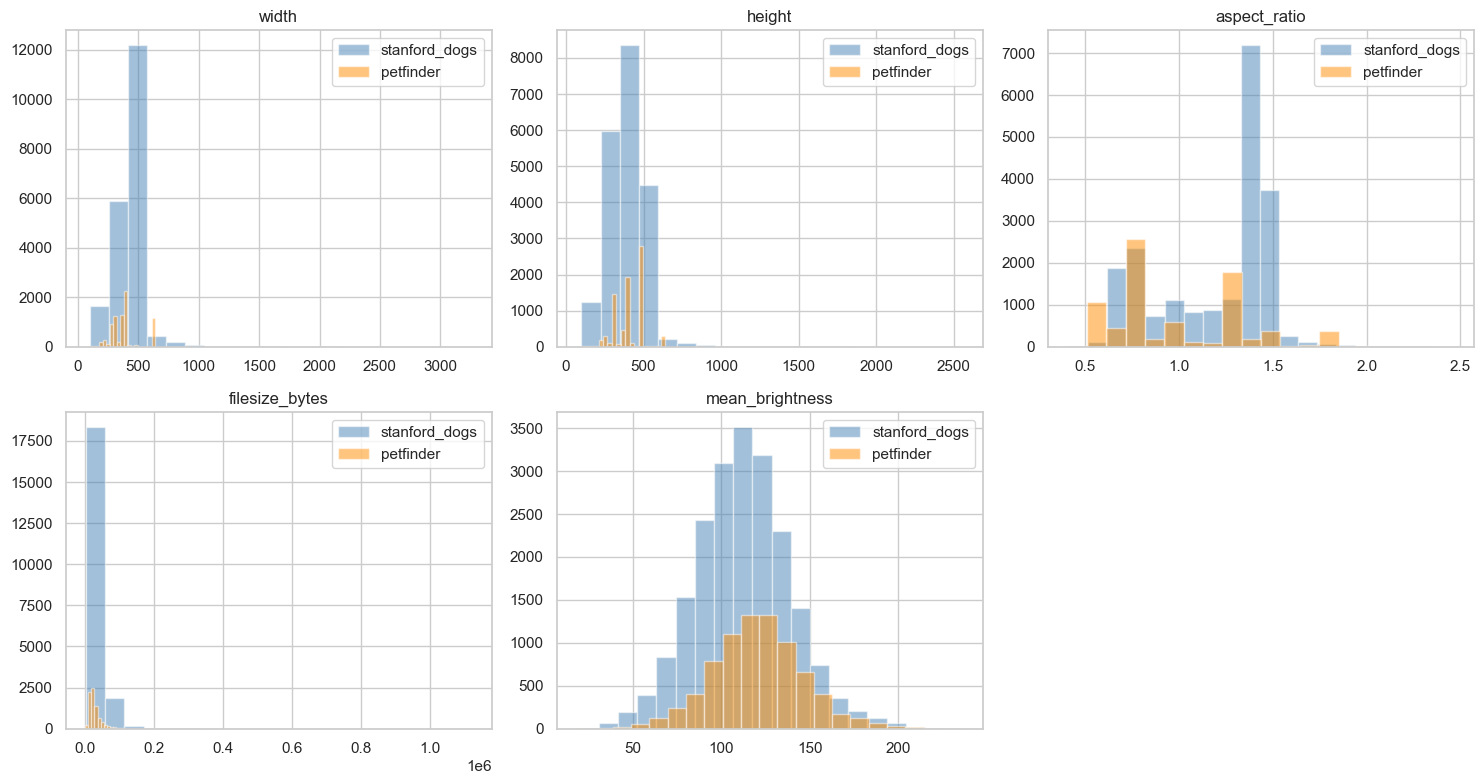

In [20]:
numeric_features = ["width", "height", "aspect_ratio", "filesize_bytes", "mean_brightness"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flat, numeric_features):
    for src, color in [("stanford_dogs", "steelblue"), ("petfinder", "darkorange")]:
        subset = manifest[manifest["source"] == src][feat]
        ax.hist(subset, bins=20, alpha=0.5, label=src, color=color)
    ax.set_title(feat)
    ax.legend()
axes.flat[-1].axis("off")
plt.tight_layout(); plt.show()

### 2.3 Bi-plots (scatter) — width vs. height, and aspect ratio vs. brightness, by source

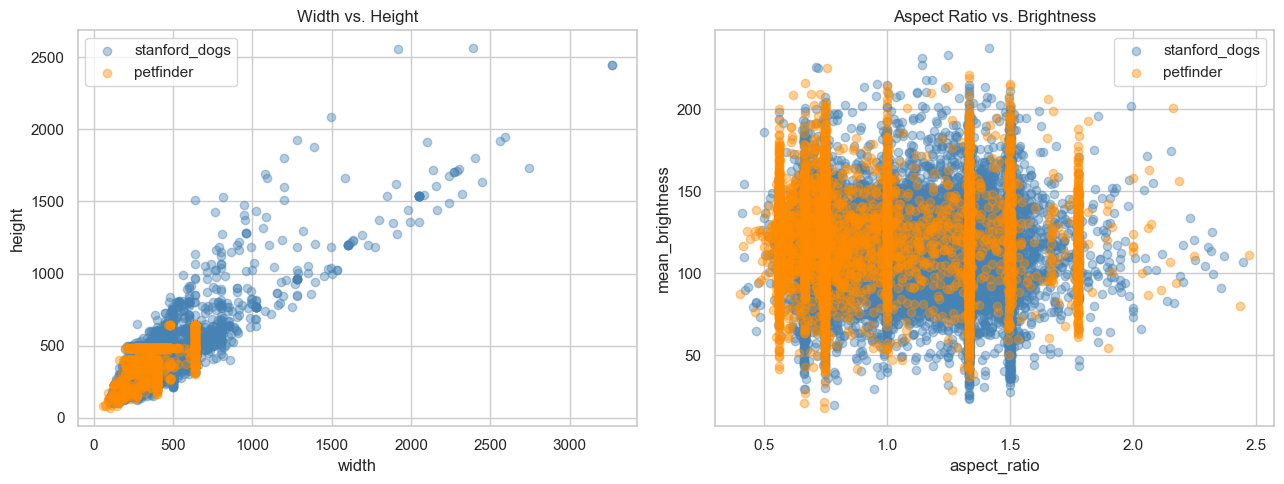

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for src, color in [("stanford_dogs", "steelblue"), ("petfinder", "darkorange")]:
    subset = manifest[manifest["source"] == src]
    axes[0].scatter(subset["width"], subset["height"], alpha=0.4, label=src, color=color)
    axes[1].scatter(subset["aspect_ratio"], subset["mean_brightness"], alpha=0.4, label=src, color=color)
axes[0].set_xlabel("width"); axes[0].set_ylabel("height"); axes[0].set_title("Width vs. Height"); axes[0].legend()
axes[1].set_xlabel("aspect_ratio"); axes[1].set_ylabel("mean_brightness"); axes[1].set_title("Aspect Ratio vs. Brightness"); axes[1].legend()
plt.tight_layout(); plt.show()

### 2.4 Pearson correlation heatmap (numeric meta-features)

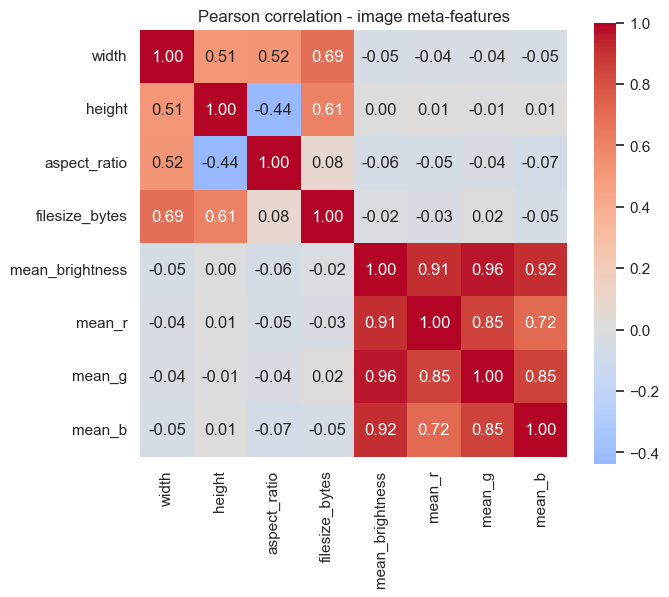

In [22]:
corr_features = ["width", "height", "aspect_ratio", "filesize_bytes", "mean_brightness", "mean_r", "mean_g", "mean_b"]
corr = manifest[corr_features].corr(method="pearson")

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Pearson correlation - image meta-features")
plt.tight_layout(); plt.show()

### 2.5 Box plots — brightness by source, aspect ratio by breed group

Splitting by "bully-type vs. other" mirrors the extra scope focus named in the proposal —
worth checking whether these breeds present any systematic photo differences before
weighting the modeling effort toward them.

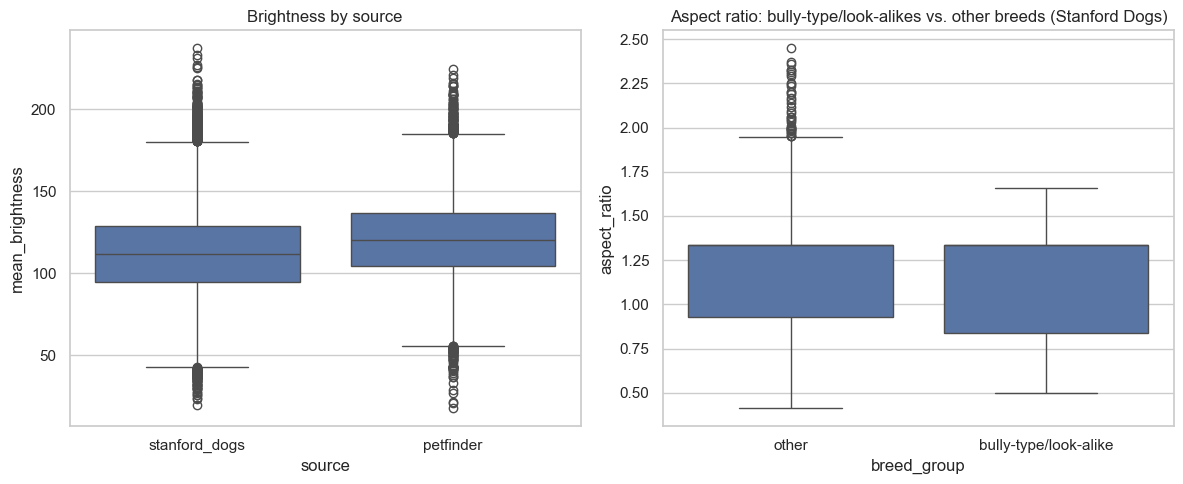

In [23]:
bully_types = {"American Staffordshire Terrier", "Boxer", "Boston Terrier"}
manifest["breed_group"] = manifest["breed_harmonized"].apply(
    lambda b: "bully-type/look-alike" if b in bully_types else "other"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=manifest, x="source", y="mean_brightness", ax=axes[0])
axes[0].set_title("Brightness by source")
sns.boxplot(data=manifest[manifest["source"]=="stanford_dogs"], x="breed_group", y="aspect_ratio", ax=axes[1])
axes[1].set_title("Aspect ratio: bully-type/look-alikes vs. other breeds (Stanford Dogs)")
plt.tight_layout(); plt.show()

### 2.6 Sample image grid, per source

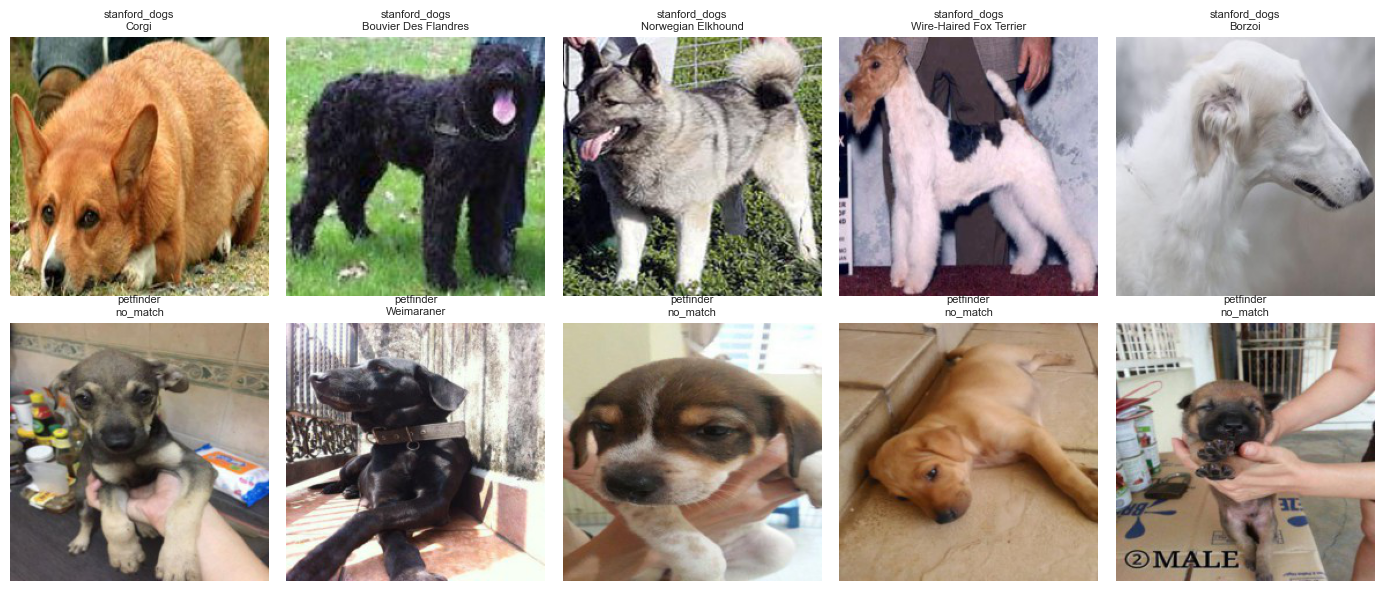

In [24]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for row_i, src in enumerate(["stanford_dogs", "petfinder"]):
    sample = manifest[manifest["source"] == src].sample(min(5, (manifest["source"]==src).sum()), random_state=1)
    for col_i, (_, r) in enumerate(sample.iterrows()):
        img = Image.open(r["resized_path"])
        axes[row_i, col_i].imshow(img)
        axes[row_i, col_i].set_title(f"{src}\n{r['breed_harmonized']}", fontsize=8)
        axes[row_i, col_i].axis("off")
plt.tight_layout(); plt.show()

### 2.7 Austin Outcomes: real-world context (not part of the image pipeline)

Grounds the problem statement in real numbers: how much of a real shelter's actual outcome
volume is tied to bully-type/"Pit Bull" labels — this is the framing data, separate from
the model's training/validation data.

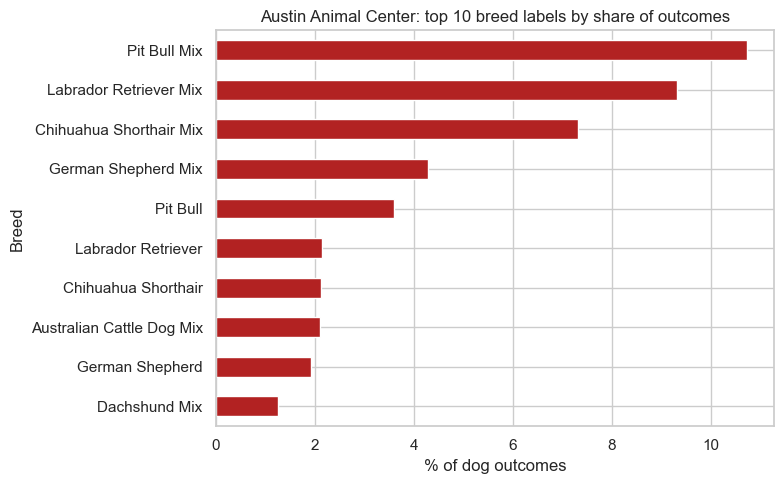

Share of dog outcomes labeled some variant of 'Pit Bull': 17.4%


In [25]:
breed_share = austin_df["Breed"].value_counts(normalize=True).head(10) * 100
plt.figure(figsize=(8, 5))
breed_share.plot(kind="barh", color="firebrick")
plt.xlabel("% of dog outcomes")
plt.title("Austin Animal Center: top 10 breed labels by share of outcomes")
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

pit_share = austin_df["Breed"].str.contains("Pit Bull", case=False, na=False).mean() * 100
print(f"Share of dog outcomes labeled some variant of 'Pit Bull': {pit_share:.1f}%")

In [26]:
pf_total = (manifest["source"]=="petfinder").sum()
pf_no_match = (manifest["breed_harmonized"]=="no_match").sum()
print(f"{pf_no_match} of {pf_total} PetFinder rows ({100*pf_no_match/pf_total:.1f}%) have no Stanford Dogs breed match")

6265 of 7869 PetFinder rows (79.6%) have no Stanford Dogs breed match


## 3. Summary — data-supported decisions carried into modeling

- **Corrupt files, exact duplicates dropped; near-duplicates flagged, not dropped** — protects
  against train/test leakage without discarding legitimate repeat photos of the same animal.
- **Non-RGB images converted, not dropped** — no usable content was lost.
- **Breed taxonomy explicitly harmonized**, with unmapped PetFinder breeds kept as `no_match`
  rather than guessed — keeps the validation step honest about what can and can't be compared.
- **Bounding-box cropping applied where annotations exist** — closest available substitute for
  segmentation given Stanford Dogs' annotation format.
- **Aspect-ratio outliers dropped; brightness outliers flagged only** — reflects that one is
  almost certainly a bad file, the other could be a real, valid photo.
- **Class imbalance confirmed on both sets** — Stanford Dogs is close to balanced (supports
  plain top-1/top-5 accuracy as a metric); PetFinder is not (confirms the proposal's decision
  to use macro-F1/per-breed precision-recall there instead of raw accuracy).
- **Domain shift between sources is visible in the meta-feature distributions** — supports the
  proposal's constraint that Stanford Dogs test accuracy won't fully transfer to real shelter
  photos, and justifies keeping PetFinder.my as a separate, real-world validation set rather
  than merging both sources into one training pool.
- **PetFinder.my breed coverage is real but partial** — of the 7,869 real PetFinder.my rows retained after cleaning, 6,265 (79.6%) have no Stanford Dogs breed equivalent and are excluded from breed-level validation. This is expected, not a data problem: PetFinder's breed vocabulary is far broader than Stanford Dogs' fixed 120 classes, and the single largest contributor is "Mixed Breed" listings, which have no true purebred label to map to in the first place — a finding that reinforces this project's own premise, since real shelter populations are dominated by mixes that don't fit clean breed categories to begin with. The rest of the gap splits between breeds genuinely absent from Stanford Dogs' 120 classes (e.g., Shiba Inu, Akita, Australian Shepherd, Chinese Crested) and generic listings too ambiguous to resolve safely (e.g., "Terrier," "Retriever," "Spaniel" alone, which could plausibly mean several different specific breeds). The remaining matched rows still substantially exceed the ≥200-real-photo validation target set in the project proposal. 


In [27]:
#Save manifest to disk
manifest.to_csv("./data/manifest.csv", index=False)